In [2]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
from tqdm import tqdm

In [3]:
YEAR = 2021
ZARR_FILEPATH = Path(f"../data/silver/ghana-{YEAR}.zarr")
CHUNKS_FOLDERPATH = Path(f"../data/silver/ghana-{YEAR}-chunks")

In [4]:
ds = xr.open_zarr(str(ZARR_FILEPATH), mask_and_scale=False, consolidated=False)
print(ds)

<xarray.Dataset> Size: 56GB
Dimensions:               (y: 73757, x: 50398)
Coordinates:
  * y                     (y) float64 590kB 11.17 11.17 11.17 ... 4.539 4.539
  * x                     (x) float64 403kB -3.261 -3.261 -3.261 ... 1.273 1.273
Data variables: (12/15)
    rededge               (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    B07                   (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    swir11                (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    cloud_confidence      (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    valid_observations    (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    nir                   (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    ...                    ...
    blue                  (y, x) uint8 4GB dask.array<chunksize=(1000, 1000), meta=np.ndarray>
    B06                   (y, x) 

None


<Axes: ylabel='Count'>

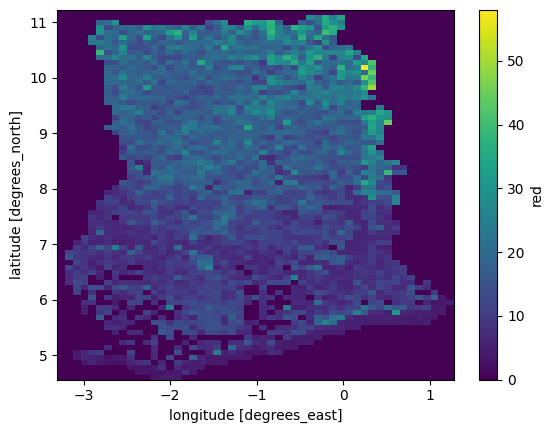

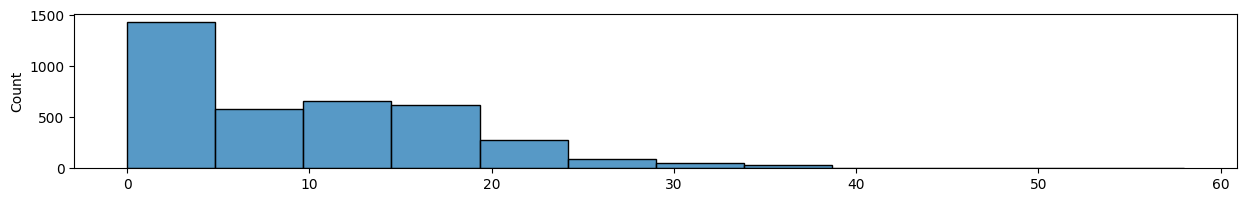

In [5]:
# Check CRS and resolution
print(ds.rio.crs)

# Downsample & plot
step = 1000
red_small_ds = ds.red.isel(y=slice(None, None, step), x=slice(None, None, step))
red_small_ds.plot()

plt.figure(figsize=(15,2))
sns.histplot(red_small_ds.values.ravel(), binwidth=5)

# Generate chunks

In [25]:
import shutil

if CHUNKS_FOLDERPATH.exists():
    shutil.rmtree(CHUNKS_FOLDERPATH)
    
CHUNKS_FOLDERPATH.mkdir(exist_ok=True)

In [26]:
SUBSAMPLE_STEP = 10 # 10 # i.e we'll have one point every 100m

In [27]:
import warnings
import numpy as np
import pandas as pd
import gc
from pathlib import Path
from tqdm import tqdm

# Define your columns and variables
band_names = ["red", "green", "blue", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
aux_names = ["cloud_confidence", "scene_classification", "valid_observations"]
grid_vars = band_names + ["cloud_confidence"]
cols = band_names + aux_names + ["ethz_map"]
computed_indices = ["tci", "ndvi", "evi", "evi2", "ndre_b5", "ndre_b6", "ndre_b7", "gndvi", "ndwi"]

chunk_size = 500 # 500
n_chunks = (ds.sizes["y"] + chunk_size - 1) // chunk_size

sizes = [3, 5, 11]
offsets = {}
for s in sizes:
    d = np.arange(-(s // 2), (s // 2) + 1)
    dy, dx = np.meshgrid(d, d, indexing='ij')
    offsets[s] = (dy.ravel(), dx.ravel())

# Helper function for safe division on arrays
def safe_div(num, den):
    return num / (den + 1e-8)
    
for i in tqdm(range(0, ds.sizes["y"], chunk_size), total=n_chunks, desc="Processing chunks"):
    
    PX_BUFFER = 5
    start_y = max(0, i - PX_BUFFER)
    end_y = min(ds.sizes["y"], i + chunk_size + PX_BUFFER)
    chunk_ds = ds[cols].isel(y=slice(start_y, end_y))
    
    valid_start = 0 if i == 0 else PX_BUFFER
    valid_end = chunk_ds.sizes['y'] - PX_BUFFER
    if i + chunk_size >= ds.sizes["y"]:
        valid_end = chunk_ds.sizes['y']
        
    y_grid = np.arange(valid_start, valid_end, SUBSAMPLE_STEP) 
    x_grid = np.arange(0, chunk_ds.sizes["x"], SUBSAMPLE_STEP)
    
    Y_pts, X_pts = np.meshgrid(y_grid, x_grid, indexing='ij')
    y_pts = Y_pts.ravel()
    x_pts = X_pts.ravel()

    # Masking optimization: stack and check all at once
    band_stack = np.stack([chunk_ds[band].values[y_pts, x_pts] for band in band_names])
    all_bands_zero = (band_stack == 0).all(axis=0)
    
    ethz_vals = chunk_ds["ethz_map"].values[y_pts, x_pts]
    keep_mask = (~all_bands_zero) & (~pd.isna(ethz_vals))

    valid_y_pts = y_pts[keep_mask]
    valid_x_pts = x_pts[keep_mask]

    if len(valid_y_pts) == 0:
        continue
        
    chunk_data = {"lon": chunk_ds.x.values[valid_x_pts], "lat": chunk_ds.y.values[valid_y_pts]}
    
    # -------------------------------------------------------------------
    # STEP 3: COMPUTE 2D INDICES UP-FRONT (Massive CPU/RAM saver)
    # -------------------------------------------------------------------
    # Pull base 2D arrays into a fast dictionary
    arrs = {col: chunk_ds[col].values for col in cols}
    
    # Compute indices on the raw 2D arrays (1 math op per pixel, not 121)
    a = arrs # shorthand
    a["tci"] = 1.2 * (a["rededge"] - a["green"]) - 1.5 * (a["red"] - a["green"]) * np.sqrt(np.maximum(a["rededge"] / (a["red"] + 1e-8), 0))
    a["ndvi"] = safe_div((a["nir"] - a["red"]), (a["nir"] + a["red"]))
    a["evi"] = 2.5 * (a["nir"] - a["red"]) / (a["nir"] + 6*a["red"] + 7.5*a["blue"] + 1.0)
    a["evi2"] = 2.5 * (a["nir"] - a["red"]) / (a["nir"] + 2.4*a["red"] + 1.0)
    a["ndre_b5"] = safe_div((a["B8A"] - a["rededge"]), (a["B8A"] + a["rededge"]))
    a["ndre_b6"] = safe_div((a["B8A"] - a["B06"]), (a["B8A"] + a["B06"]))
    a["ndre_b7"] = safe_div((a["B8A"] - a["B07"]), (a["B8A"] + a["B07"]))
    a["gndvi"] = safe_div((a["nir"] - a["green"]), (a["nir"] + a["green"]))
    a["ndwi"] = safe_div((a["nir"] - a["swir11"]), (a["nir"] + a["swir11"]))

    # Extract 1x1 Center Pixels directly from the 2D arrays
    for col in cols + computed_indices:
        chunk_data[col] = a[col][valid_y_pts, valid_x_pts]

    # -------------------------------------------------------------------
    # STEP 4: WINDOW EXTRACTION
    # -------------------------------------------------------------------
    features_to_window = grid_vars + computed_indices
    max_y, max_x = a["red"].shape[0] - 1, a["red"].shape[1] - 1

    # Suppress warnings for calculating stats on all-NaN slices
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        for s in sizes:
            dy, dx = offsets[s]
            suffix = f"{s}x{s}"
            
            # Pre-compute coordinates and clip once per size, not per band
            win_y = np.clip(valid_y_pts[:, None] + dy, 0, max_y)
            win_x = np.clip(valid_x_pts[:, None] + dx, 0, max_x)
            
            for feat in features_to_window:
                # Extract window for this specific feature and compute metrics
                # Casting to float32 is required to allow np.nan insertion
                windows = a[feat][win_y, win_x].astype(np.float32)
                
                # Convert 0s to NaNs for features in band_names
                if feat in band_names:
                    windows[windows == 0] = np.nan
                
                # Use NaN-aware numpy functions
                chunk_data[f"{feat}_{suffix}_median"] = np.nanmedian(windows, axis=1)
                chunk_data[f"{feat}_{suffix}_min"] = np.nanmin(windows, axis=1)
                chunk_data[f"{feat}_{suffix}_max"] = np.nanmax(windows, axis=1)
                chunk_data[f"{feat}_{suffix}_var"] = np.nanvar(windows, axis=1)

    # Dump directly to Parquet
    df_chunk = pd.DataFrame(chunk_data)
    
    # Downcast to float32
    float_cols = df_chunk.select_dtypes(include=['float64']).columns
    if len(float_cols) > 0:
        df_chunk[float_cols] = df_chunk[float_cols].astype(np.float32)
    
    df_chunk.to_parquet(CHUNKS_FOLDERPATH / f"chunk_{i:05d}.parquet")
    
    # Clean up to keep RAM flat
    del arrs, chunk_data, df_chunk, chunk_ds, band_stack
    gc.collect()

print("Processing complete!")

Processing chunks: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [59:28<00:00, 24.11s/it]

Processing complete!
